# Overlap simulations — when averaging fails and deconvolution doesn't

Overlap is the reason deconvolution exists. This notebook simulates it on purpose, in
the two senses the word carries, and checks what each estimator recovers against the
*known* injected kernel:

| | what overlaps | knob | what it breaks |
|---|---|---|---|
| **Part A** | consecutive events of the *same* type | the ISI | epoch-and-average (ERP) picks up the neighbours' tails |
| **Part B** | two *different* event types at a near-fixed lag | the stimulus→response jitter | the two kernels become collinear — nothing can separate them |

The two results, up front:

- **Part A.** Once the mean ISI drops below the length of the kernel, the ERP degrades
  badly while the TRF does not. At a 150 ms ISI the ERP correlates 0.60 with the true
  kernel; the TRF, from the same data, reaches 0.997.
- **Part B.** Collinearity, not overlap, is the binding constraint for categorical
  designs — and it takes remarkably little to break it. With the response locked to a
  rigid 300 ms lag the design carries generalized VIFs of 93 and 322 (against a flag
  level of `√10 ≈ 3.2`) and the response kernel is recovered at 0.63. Adding ±5 ms of
  jitter — less than one sample at 128 Hz — drops both below 1.7 and lifts recovery
  to 0.97.

Everything is built from the public `trflearn.simulation` API
(`ExperimentDesign`, `CompoundKernel`, `EEGSimulator`, `to_features`) and fitted
with `trflearn`. The ridge penalty is
always chosen by cross-validation (`fit_trf_cv`), never fixed by hand, and design
identifiability is read off `trflearn`'s own `vif_` diagnostic. Single channel
throughout — overlap is a *temporal* phenomenon, so a montage would only add noise to
the story.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trflearn import TRFData, TRFModel
from trflearn.simulation import (
    ExperimentDesign, EEGSimulator, CompoundKernel,
    build_uniform_isi_sampler, assign_event_latencies, to_features,
)

SR = 128                               # Hz
WINDOW = (-0.2, 0.5)                   # TRF / epoch window (s)
GRID = np.logspace(-6, 4, 11)   # ridge penalties swept by gridsearchCV
print("sample rate:", SR, "Hz | window:", WINDOW, "s")

sample rate: 128 Hz | window: (-0.2, 0.5) s


## 0 · Helpers

Four small utilities the rest of the notebook leans on. `epoch_average` is the naive
baseline that overlap is supposed to break; `trf_kernel` pulls the recovered kernel
off a fitted model; `kernel_on_grid` and `unit_peak` put the truth and the estimate on
comparable footing.

In [2]:
def epoch_average(y, latencies, sfreq, tmin, tmax):
    """Naive epoch-and-average (ERP). Returns (times, erp, n_used)."""
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[:, None]
    i0, i1 = int(round(tmin * sfreq)), int(round(tmax * sfreq))
    times = np.arange(i0, i1 + 1) / sfreq
    epochs = [y[lat + i0: lat + i1 + 1]
              for lat in np.asarray(latencies, dtype=int)
              if lat + i0 >= 0 and lat + i1 + 1 <= len(y)]
    if not epochs:
        raise ValueError("no epoch fits inside the signal")
    return times, np.mean(epochs, axis=0), len(epochs)


def trf_kernel(model, spec):
    """(times_s, kernel) for a fitted feature; channel-mean, first sub-feature."""
    delays = next(np.asarray(b["delays"]) for b in model._blocks if b["spec"] == spec)
    coef = model.coef_[spec].detach().cpu().numpy()      # (C, d, |D|)
    return delays / model.sample_rate, coef[:, 0, :].mean(axis=0)


def kernel_on_grid(kernel, times_s):
    """The injected CompoundKernel resampled onto an arbitrary time grid (0 outside)."""
    return np.interp(np.asarray(times_s, float),
                     kernel.time, kernel.waveform, left=0.0, right=0.0)


def unit_peak(x):
    """Scale to unit peak — the model works in sigma units, so only shape is comparable."""
    x = np.asarray(x, float)
    return x / (np.abs(x).max() + 1e-12)

<a id="overlap-handling"></a>

---
# Part A · Temporal overlap — the ISI and the ERP bias

One event type, one kernel. The only thing that changes between conditions is how
close together the events land.

### A1 · The ground truth

A P1–N1-ish kernel, ~350 ms long. Any ISI shorter than that guarantees overlap.

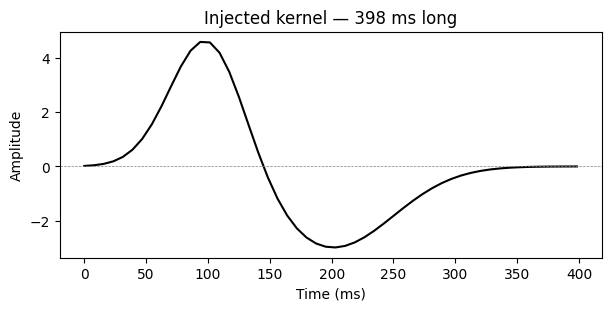

In [3]:
stim_kernel = CompoundKernel("stimulus", sfreq=SR)
stim_kernel.add(peak_latency=0.10, amplitude=5.0, width=0.03)
stim_kernel.add(peak_latency=0.20, amplitude=-3.0, width=0.05)

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(stim_kernel.time * 1e3, stim_kernel.waveform, color="k")
ax.axhline(0, lw=.5, ls="--", color="grey")
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Amplitude")
ax.set_title(f"Injected kernel — {stim_kernel.time[-1]*1e3:.0f} ms long")
fig
plt.show()

### A2 · One simulation, parametrised by ISI

`n_events` is held **fixed** across conditions and the duration is derived from the
ISI, so every condition averages the same number of epochs — otherwise a short-ISI
run would look better simply for having more trials.

`fit_trf_cv` selects the ridge penalty per condition via `gridsearchCV` over
`GRID` — it is the only fitting routine in the notebook, so every reported
correlation reflects whatever penalty cross-validation picked for that condition.

In [4]:
def simulate_isi(mean_isi_s, n_events=400, jitter_frac=0.7, seed=0, noise=0.5):
    """Simulate one single-event-type recording at a given mean ISI."""
    duration_s = mean_isi_s * (n_events + 5)
    width = int(round(mean_isi_s * jitter_frac * SR))     # uniform ISI spread, samples
    offset = int(round(mean_isi_s * SR)) - width // 2

    design = ExperimentDesign(
        n_events=n_events, event_types=["stimulus"], sfreq=SR,
        duration_s=duration_s,
        isi_sampler=build_uniform_isi_sampler(
            width=width, offset=offset, rng=np.random.default_rng(seed)),
        seed=seed,
    )
    events = design.generate_events()
    features = design.generate_features(events)

    sim = EEGSimulator(sfreq=SR, duration=duration_s)
    sim.add_kernel(stim_kernel, activation=lambda row: row["type"] == "stimulus")
    sim.set_events(events)
    sim.simulate()
    sim.add_noise(colour="pink", scale=noise * float(sim.data.std()),
                  rng=np.random.default_rng(seed))
    return events, features, sim

In [5]:
def fit_trf_cv(features, y, feature_names, feature_windows=None,
               regularization_grid=GRID):
    """Fit a TRF, selecting the ridge penalty via gridsearchCV over regularization_grid.

    `feature_windows` is passed straight through to `TRFModel`; it is only used
    in B3, where the two blocks are deliberately given different widths.
    """
    data = TRFData(features=features, y=np.asarray(y, dtype="float32"), sample_rate=SR)
    data.create_partitions(n_folds=5)
    model = TRFModel(TRFDataset=data, features=feature_names,
                     default_window=WINDOW, feature_windows=feature_windows,
                     solver="ridge")
    best_regularization, _ = model.gridsearchCV(regularization_grid, validation_plot=False)
    return model, best_regularization

### A3 · Long ISI vs short ISI

At a long ISI the epochs are clean and both estimators land on the kernel. At a short
ISI each epoch also contains the tail of the previous response — the ERP inherits
that; the TRF does not. Both correlations are printed so the gap is a number, not an
impression.

In [6]:
conditions = {"long ISI (2.5 s)": 2.5, "short ISI (0.15 s)": 0.15}
results = {}

for label, isi in conditions.items():
    events, features, sim = simulate_isi(isi)
    lat = events.loc[events["type"] == "stimulus", "latency"].to_numpy()

    t_erp, erp, n_used = epoch_average(sim.data, lat, SR, *WINDOW)
    model, best_regularization = fit_trf_cv(features, sim.data, ["stimulus"])
    t_trf, trf = trf_kernel(model, "stimulus")

    r_erp = np.corrcoef(kernel_on_grid(stim_kernel, t_erp), erp[:, 0])[0, 1]
    r_trf = np.corrcoef(kernel_on_grid(stim_kernel, t_trf), trf)[0, 1]

    results[label] = dict(t_erp=t_erp, erp=erp[:, 0], t_trf=t_trf, trf=trf,
                          best_regularization=best_regularization, n_used=n_used, n_events=len(lat))
    print(f"{label:20s} events={len(lat):5d}  epochs averaged={n_used:5d}  "
          f"r(ERP)={r_erp:.3f}   r(TRF, CV λ={best_regularization:.2g})={r_trf:.3f}")

long ISI (2.5 s)     events=  398  epochs averaged=  397  r(ERP)=1.000   r(TRF, CV α=1e+02)=1.000
short ISI (0.15 s)   events=  391  epochs averaged=  387  r(ERP)=0.596   r(TRF, CV α=0.001)=0.997


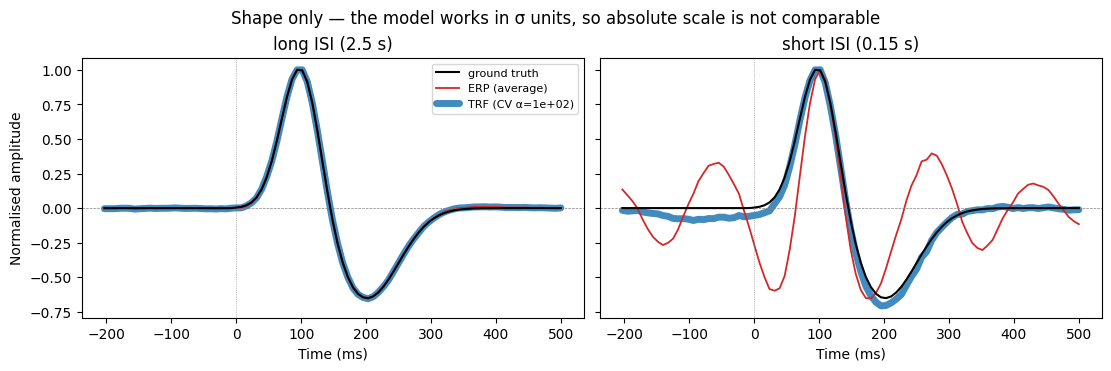

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, constrained_layout=True)
for ax, (label, r) in zip(axes, results.items()):
    gt = kernel_on_grid(stim_kernel, r["t_trf"])
    ax.plot(r["t_trf"] * 1e3, unit_peak(gt), "k", lw=1.5, zorder=3,
            label="ground truth")
    ax.plot(r["t_erp"] * 1e3, unit_peak(r["erp"]), "C3", lw=1.3, zorder=2,
            label="ERP (average)")
    ax.plot(r["t_trf"] * 1e3, unit_peak(r["trf"]), "C0", lw=5.0, alpha=.85, zorder=1,
            solid_capstyle="round", label=f"TRF (CV λ={r['best_regularization']:.2g})")
    ax.axhline(0, lw=.5, ls="--", color="grey"); ax.axvline(0, lw=.5, ls=":", color="grey")
    ax.set_title(label); ax.set_xlabel("Time (ms)")
axes[0].set_ylabel("Normalised amplitude")
axes[0].legend(fontsize=8)
fig.suptitle("Shape only — the model works in σ units, so absolute scale is not comparable")
fig
plt.show()

### A4 · ISI sweep

Correlation with the ground truth (scale-invariant, so it compares the two estimators
fairly) as the mean ISI shrinks from "no overlap" to "heavy overlap". The ERP tracks
the TRF until the ISI reaches the kernel length, then falls away from it; the TRF
stays at ceiling across the whole range.

In [8]:
isis = [0.15, 0.2, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0]
rows = []

for isi in isis:
    events, features, sim = simulate_isi(isi)
    lat = events.loc[events["type"] == "stimulus", "latency"].to_numpy()

    t_erp, erp, _ = epoch_average(sim.data, lat, SR, *WINDOW)
    model, best_regularization = fit_trf_cv(features, sim.data, ["stimulus"])
    t_trf, trf = trf_kernel(model, "stimulus")

    rows.append(dict(
        isi=isi,
        r_erp=np.corrcoef(kernel_on_grid(stim_kernel, t_erp), erp[:, 0])[0, 1],
        r_trf=np.corrcoef(kernel_on_grid(stim_kernel, t_trf), trf)[0, 1],
        best_regularization=best_regularization,
    ))

sweep_a = pd.DataFrame(rows)
sweep_a

,isi,r_erp,r_trf,best_alpha
0,0.15,0.596002,0.996786,0.001000
1,0.20,0.757332,0.993397,0.010000
2,0.30,0.916884,0.998753,0.010000
3,0.50,0.975900,0.999867,0.000010
4,0.80,0.999852,0.999817,0.000001
5,1.20,0.999930,0.999927,0.100000
6,2.00,0.999961,0.999961,0.000001
7,3.00,0.999965,0.999965,100.000000


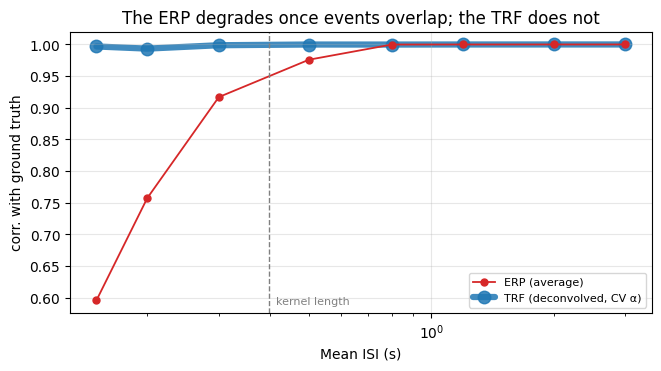

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.6), constrained_layout=True)
ax.plot(sweep_a["isi"], sweep_a["r_erp"], "o-", color="C3", lw=1.3, ms=5, zorder=2,
        label="ERP (average)")
ax.plot(sweep_a["isi"], sweep_a["r_trf"], "o-", color="C0", lw=4.5, ms=9, alpha=.85,
        zorder=1, solid_capstyle="round", label="TRF (deconvolved, CV λ)")
ax.axvline(stim_kernel.time[-1], ls="--", color="grey", lw=1)
ax.text(stim_kernel.time[-1], 0.03, "  kernel length", color="grey", fontsize=8,
        transform=ax.get_xaxis_transform())
ax.set_xscale("log"); ax.set_xlabel("Mean ISI (s)")
ax.set_ylabel("corr. with ground truth")
ax.set_title("The ERP degrades once events overlap; the TRF does not")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.3)
fig
plt.show()

---
# Part B · Structural overlap — stimulus→response collinearity

Now two event types, where the second reliably trails the first. Here the ISI is not
the problem: the problem is that if `response` *always* lands 300 ms after
`stimulus`, the two lagged regressors are the same column shifted, and **no**
estimator can attribute the signal to one rather than the other. The jitter around
that lag is the only thing that makes the pair identifiable.

### B1 · A paired design

`ExperimentDesign` cycles event types independently, so the paired structure is built
directly here: lay out the `stimulus` onsets with the usual ISI sampler, then hang a
`response` off each one at `lag ± jitter`. `to_features` then turns that table into
one impulse train per event type, as `generate_features` does for a designed one.

In [10]:
def build_paired_events(n_pairs, duration_s, isi_sampler, lag_s, jitter_s, rng):
    """Events where each `response` trails its `stimulus` by lag_s ± jitter_s."""
    firsts = pd.DataFrame({"type": ["stimulus"] * int(n_pairs)})
    firsts = assign_event_latencies(firsts, isi_sampler)

    offsets = lag_s + rng.uniform(-jitter_s, jitter_s, size=len(firsts))
    seconds = pd.DataFrame({
        "type": "response",
        "latency": firsts["latency"].to_numpy() + np.round(offsets * SR).astype(int),
    })

    events = pd.concat([firsts, seconds], ignore_index=True)
    events = events[(events["latency"] >= 0) & (events["latency"] < int(duration_s * SR))]
    events = events.sort_values("latency").reset_index(drop=True)
    events["latency_s"] = events["latency"] / SR
    return events


resp_kernel = (CompoundKernel("response", sfreq=SR)
               .add(peak_latency=0.06, amplitude=4.0, width=0.02)
               .add(peak_latency=0.16, amplitude=2.0, width=0.04))

In [11]:
def simulate_paired(jitter_s, n_pairs=400, mean_isi_s=1.5, lag_s=0.3, seed=0, noise=0.5):
    """Simulate a stimulus→response paired design at a given jitter."""
    duration_s = mean_isi_s * (n_pairs + 5)
    width = int(round(mean_isi_s * 0.4 * SR))
    events = build_paired_events(
        n_pairs, duration_s,
        isi_sampler=build_uniform_isi_sampler(
            width=width, offset=int(round(mean_isi_s * SR)) - width // 2,
            rng=np.random.default_rng(seed)),
        lag_s=lag_s, jitter_s=jitter_s, rng=np.random.default_rng(seed + 1),
    )
    n_samples = int(duration_s * SR)
    features = to_features(events, n_samples)

    sim = EEGSimulator(sfreq=SR, duration=duration_s)
    sim.add_kernel(stim_kernel, activation=lambda row: row["type"] == "stimulus")
    sim.add_kernel(resp_kernel, activation=lambda row: row["type"] == "response")
    sim.set_events(events)
    sim.simulate()
    sim.add_noise(colour="pink", scale=noise * float(sim.data.std()),
                  rng=np.random.default_rng(seed))
    return events, features, sim

### B2 · Rigid lag vs jittered lag

`jitter=0` is the degenerate case — a constant 300 ms offset. Whatever the fit
returns for the two kernels there, it is one of infinitely many equivalent
splits of the same signal.

In [12]:
jitter_conditions = {"rigid lag (jitter 0 ms)": 0.0, "jittered lag (± 150 ms)": 0.15}
paired_results = {}

for label, jit in jitter_conditions.items():
    events, features, sim = simulate_paired(jit)
    model, best_regularization = fit_trf_cv(features, sim.data, ["stimulus", "response"])
    paired_results[label] = {
        spec: trf_kernel(model, spec) for spec in ("stimulus", "response")}
    print(f"{label:26s} events={len(events):5d}  CV λ={best_regularization:.2g}")

rigid lag (jitter 0 ms)    events=  798  CV α=0.001


jittered lag (± 150 ms)    events=  798  CV α=0.01


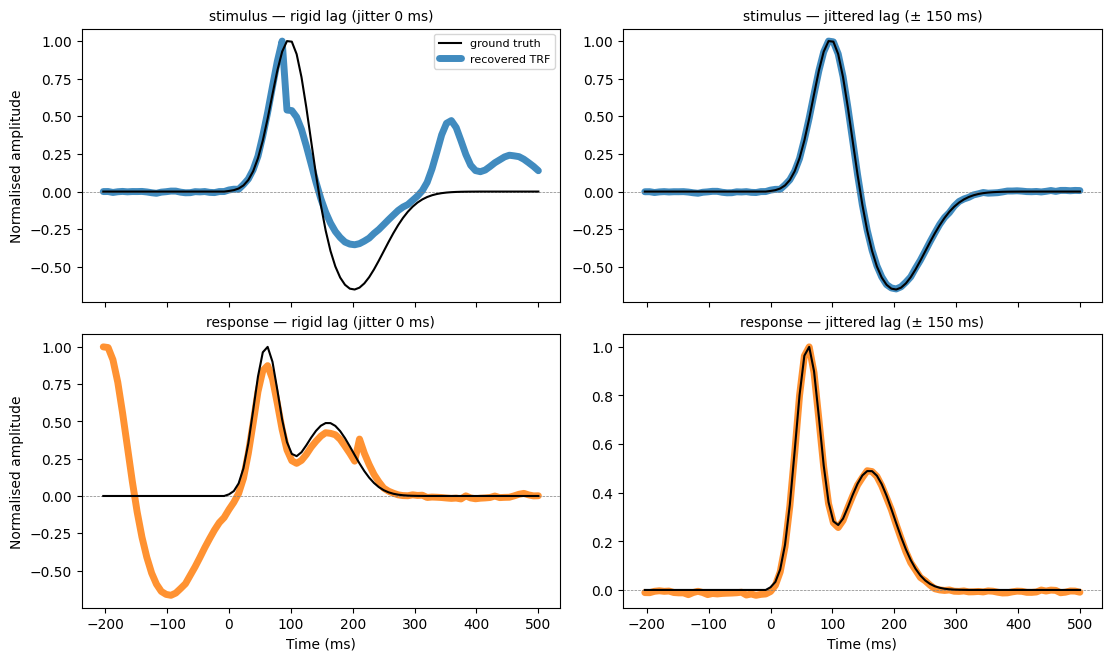

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, constrained_layout=True)
truth = {"stimulus": stim_kernel, "response": resp_kernel}

for col, (label, kernels) in enumerate(paired_results.items()):
    for row, spec in enumerate(("stimulus", "response")):
        ax = axes[row, col]
        t, k = kernels[spec]
        ax.plot(t * 1e3, unit_peak(kernel_on_grid(truth[spec], t)), "k", lw=1.5,
                zorder=3, label="ground truth")
        ax.plot(t * 1e3, unit_peak(k), f"C{row}", lw=5.0, alpha=.85, zorder=1,
                solid_capstyle="round", label="recovered TRF")
        ax.axhline(0, lw=.5, ls="--", color="grey")
        ax.set_title(f"{spec} — {label}", fontsize=10)
        if row == 1:
            ax.set_xlabel("Time (ms)")
        if col == 0:
            ax.set_ylabel("Normalised amplitude")
axes[0, 0].legend(fontsize=8)
fig
plt.show()

<a id="vif-multicollinearity"></a>

### B3 · Jitter sweep

How much jitter is *enough*? Recovery of both kernels as the jitter widens, with
`trflearn`'s VIF diagnostic (`model.vif_`) alongside as the mechanism behind it.

`vif_` gives **one generalized VIF per TRF** — how much of that feature's block is
explained by the other blocks, with `1.0` meaning none. It is reported on the scale of
`sqrt(VIF)`, so the conventional "VIF > 10" rule sits at `√10 ≈ 3.2`, the dotted line
in the plot. The two features get different delay windows here (`stimulus` 116 delays,
`response` 91), which is what makes the two grey traces readable apart: they share one
collinearity relationship, and the narrower block carries more of it per coefficient.

The grey traces are the thing to read. At a rigid lag the design is badly collinear —
93 and 322, far past the flag — and both kernels are recovered poorly. ±5 ms of jitter
drops both below 1.7, and by ±40 ms they sit at ~1.0 and the design is effectively
clean. The recovery curves track them the whole way up. That is the practical point of
Part B: **very little jitter is enough**.

In [14]:
# sampled densely at the low end: that is where the interesting change happens
jitters = [0.0, 0.005, 0.01, 0.02, 0.04, 0.08, 0.15, 0.3]

# Unequal block widths (116 delays vs 91) are what let the two VIF entries be read
# apart; the stimulus kernel is the longer of the two, so it gets the wider window.
FEATURE_WINDOWS = {"stimulus": (-0.3, 0.6)}
rows = []

for jit in jitters:
    events, features, sim = simulate_paired(jit)
    model, best_regularization = fit_trf_cv(features, sim.data, ["stimulus", "response"],
                                   FEATURE_WINDOWS)

    # One generalized VIF per TRF, in the order the features were declared. Computed
    # on the unregularized design, so it describes the design and not the fitted λ.
    vif_stimulus, vif_response = model.vif_

    row = {"jitter_ms": jit * 1e3,
           "vif_stimulus": vif_stimulus,
           "vif_response": vif_response,
           "best_regularization": best_regularization}
    for spec, kern in (("stimulus", stim_kernel), ("response", resp_kernel)):
        t, k = trf_kernel(model, spec)
        row[f"r_{spec}"] = np.corrcoef(kernel_on_grid(kern, t), k)[0, 1]
    rows.append(row)

sweep_b = pd.DataFrame(rows)
sweep_b.round(4)

,jitter_ms,vif_stimulus,vif_response,best_alpha,r_stimulus,r_response
0,0.0,92.7841,322.0984,0.010,0.8602,0.6255
1,5.0,1.4677,1.6309,0.001,0.9833,0.9587
2,10.0,1.2592,1.3416,0.001,0.9917,0.9774
3,20.0,1.1252,1.1623,0.010,0.9776,0.9529
4,40.0,1.0599,1.0770,0.010,0.9925,0.9855
5,80.0,1.0274,1.0351,0.010,0.9990,0.9984
6,150.0,1.0124,1.0158,0.010,0.9999,0.9998
7,300.0,1.0044,1.0056,0.100,0.9991,0.9997


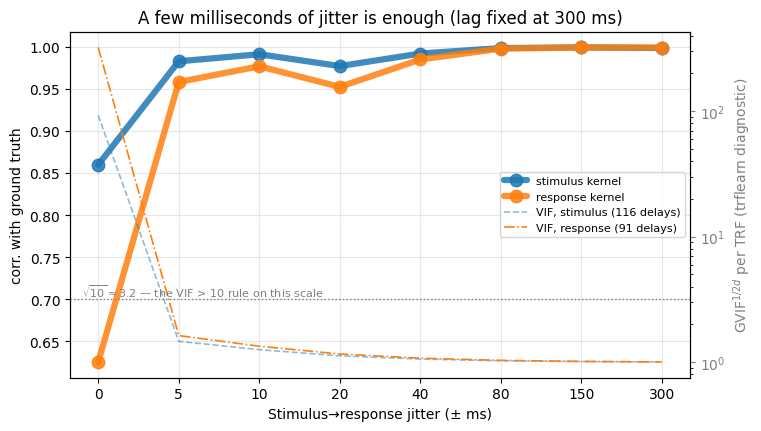

In [15]:
# the sampled jitters are spaced evenly on the x-axis: the whole story is in the
# first two points, which a linear axis would squeeze into the left-hand margin
x = np.arange(len(sweep_b))

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(x, sweep_b["r_stimulus"], "o-", color="C0", lw=4.5, ms=9, alpha=.85,
        zorder=2, solid_capstyle="round", label="stimulus kernel")
ax.plot(x, sweep_b["r_response"], "o-", color="C1", lw=4.5, ms=9, alpha=.85,
        zorder=2, solid_capstyle="round", label="response kernel")
ax.set_xticks(x)
ax.set_xticklabels([f"{j:g}" for j in sweep_b["jitter_ms"]])
ax.set_xlabel("Stimulus→response jitter (± ms)")
ax.set_ylabel("corr. with ground truth")
ax.set_title("A few milliseconds of jitter is enough (lag fixed at 300 ms)")
ax.grid(alpha=.3)

# One GVIF per TRF. The blocks share a single collinearity relationship, so the pair
# differs only by the 1/2d root taken of it -- the narrower response block reports the
# higher value. The gap is therefore fixed on the log scale, which is why the traces
# fork at the left and merge once both approach 1.0. Log axis: two orders of magnitude.
ax2 = ax.twinx()
ax2.plot(x, sweep_b["vif_stimulus"], "--", color="C0", lw=1.2, alpha=.5,
         zorder=1, label="VIF, stimulus (116 delays)")
ax2.plot(x, sweep_b["vif_response"], "-.", color="C1", lw=1.2, ms=4,
         zorder=1, label="VIF, response (91 delays)")
# GVIF^(1/2d) is on the scale of sqrt(VIF), so the usual "VIF > 10" rule is sqrt(10)
ax2.axhline(np.sqrt(10), ls=":", color="grey", lw=1)
ax2.text(0.02, np.sqrt(10), r"$\sqrt{10}\approx3.2$ — the VIF > 10 rule on this scale",
         color="grey", fontsize=8, va="bottom", transform=ax2.get_yaxis_transform())
ax2.set_yscale("log")
ax2.set_ylabel(r"GVIF$^{1/2d}$ per TRF (trflearn diagnostic)", color="grey")
ax2.tick_params(axis="y", colors="grey")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
fig
plt.show()

---
## Summary

Two different failures, two different lessons.

**Overlap breaks averaging, not deconvolution.** Averaging assumes each epoch contains
one response. Once the mean ISI falls below the kernel length that assumption is
false — every epoch carries its neighbours' tails, and the ERP inherits them as
spurious structure. Deconvolution never makes the assumption in the first place: it
attributes the signal to the events that could have produced it, so it is indifferent
to how tightly they are packed. In the sweep the ERP falls from 1.00 to 0.60 as the ISI
shrinks from 3 s to 150 ms, while the TRF stays above 0.99 throughout.

**But deconvolution has its own precondition: an identifiable design.** If a second
event type always follows the first at a rigid lag, the two lagged regressors are the
same column shifted. That degeneracy is not an estimation problem to be solved with
more data or better regularization — the information is simply absent, and the fit
returns one of infinitely many equivalent splits of the same signal. `trflearn` reports
it directly: at zero jitter the generalized VIFs are 93 and 322, thirty to a hundred
times past the `√10 ≈ 3.2` level that corresponds to the conventional "VIF > 10" flag.

**The good news is how cheaply the degeneracy is broken.** The response GVIF goes
322 → 1.63 → 1.34 for jitters of 0, ±5 and ±10 ms, and recovery of that kernel follows
it: 0.63 → 0.97 → 0.98. At 128 Hz, ±5 ms is less than one sample — the event onsets move by
at most a single sample — and that is already enough to take the design from severely
collinear to essentially clean. Past ~40 ms GVIF is within a few percent of 1 and both
kernels sit at ceiling, so wider jitter buys nothing further.

The practical reading for a categorical design: overlap between conditions is not
something to design away, and shortening the ISI to collect more events is a good
trade. What genuinely must be avoided is a *fixed* temporal relationship between event
types — and a few milliseconds of jitter is enough to avoid it.

### Caveats

- Correlation with the ground truth is scale-invariant, which is what makes the ERP
  and the TRF comparable at all, but it says nothing about amplitude bias — a real
  part of the overlap problem that these numbers do not capture.
- The ERP baseline is deliberately the textbook one: no baseline correction, no trial
  rejection. Those would soften the short-ISI failure without removing its cause.
- `vif_` describes the unregularized design on purpose. The related
  `condition_number_` is computed on the *regularized* normal matrix, so it moves with
  the cross-validated λ and mixes design geometry with penalty strength — it is not
  the right one for this plot.
- With two feature blocks there is one collinearity relationship, so both entries of
  `vif_` derive from the same raw GVIF; they differ only because the `1/2d` root is
  taken over 116 delays for `stimulus` and 91 for `response`. Give the two features the
  same window and the two entries become the same float exactly — the separation in the
  plot is the block widths talking, not one feature being worse off than the other.
  Read `vif_aliased_` alongside `vif_` too, since an *exact* dependency is deliberately
  excluded from the determinants and reports as 1.0 rather than infinity.
- Single channel, stationary kernels, pink noise at a fixed SNR, one seed per
  condition. The small non-monotonicities in the sweeps (for instance the ±20 ms point
  in Part B) are run-to-run wobble at that noise level, not structure.